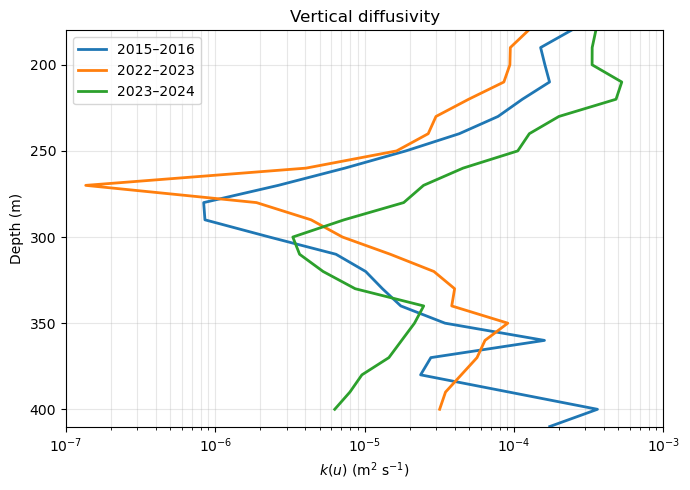

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# file names
# =========================================================
files = {
    "2015–2016": "mixing_scan_u_station690_2015_vs_station951_2016_aligned.csv",
    "2022–2023": "mixing_scan_u_station367_2022_vs_station446_2023_aligned.csv",
    "2023–2024": "mixing_scan_u_station446_2023_vs_station519_2024_aligned.csv",
}

# =========================================================
# read csv
# =========================================================
def read_scan_csv(file_path):
    df = pd.read_csv(file_path)

    required_cols = ["u_depth_actual", "k_u"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"{file_path} missing column {col}")

    return df


# =========================================================
# remove specific depths
# =========================================================
def remove_bad_depths(label, df):

    if label == "2022–2023":
        df = df[~np.isclose(df["u_depth_actual"], 380)]

    if label == "2023–2024":
        df = df[~np.isclose(df["u_depth_actual"], 360)]

    if label == "2015–2016":
        df = df[~np.isclose(df["u_depth_actual"], 390)]

    return df


# =========================================================
# plotting
# =========================================================
def plot_diffusivity_profiles(file_dict, save_path=None):

    fig, ax = plt.subplots(figsize=(7,5))

    all_k = []

    for label, file_path in file_dict.items():

        df = read_scan_csv(file_path)

        df = remove_bad_depths(label, df)

        mask = (
            np.isfinite(df["k_u"]) &
            (df["k_u"] > 0) &
            np.isfinite(df["u_depth_actual"])
        )

        df = df.loc[mask]

        all_k.extend(df["k_u"])

        ax.plot(
            df["k_u"],
            df["u_depth_actual"],
            linewidth=2,
            label=label
        )

    # =====================================================
    # better log scale limits
    # =====================================================

    k_min = np.min(all_k)
    k_max = np.max(all_k)

    # round to nice log limits
    xmin = 10**np.floor(np.log10(k_min))
    xmax = 10**np.ceil(np.log10(k_max))

    ax.set_xscale("log")
    ax.set_xlim(xmin, xmax)

    # consistent depth axis
    ax.set_ylim(410,180)

    ax.set_xlabel(r"$k(u)$ (m$^2$ s$^{-1}$)")
    ax.set_ylabel("Depth (m)")
    ax.set_title("Vertical diffusivity")

    ax.grid(True, which="both", alpha=0.3)

    ax.legend()

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# =========================================================
# run
# =========================================================
plot_diffusivity_profiles(
    files,
    save_path="diffusivity_profiles_combined.png"
)